# Multi-band HP + IHB optimization — fleet summary

**Run:** `python run_multiband_potential.py` (16 representative days, 8 workers, 2025 costs)

**System:** shared on-site solar → heat pumps (<200 °C, COP 2.7/1.8) and resistive IHB (>200 °C, COP 1.0), each with 16 h thermal storage (92% RTE). Land-capped at 50 MWdc/km².

**Outputs:** `outputs/multiband_hp_ihb_by_facility.csv` · this notebook writes `outputs/analysis/multiband_optimization_summary.txt`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve().parent if Path.cwd().name == "analysis" else Path(".").resolve()
if not (ROOT / "outputs" / "multiband_hp_ihb_by_facility.csv").exists():
    ROOT = Path.cwd()
OUT = ROOT / "outputs" / "analysis"
OUT.mkdir(parents=True, exist_ok=True)

opt = pd.read_csv(ROOT / "outputs" / "multiband_hp_ihb_by_facility.csv")
ok = opt[opt["status"] == "ok"].copy()
w = ok["replaceable_heat_mwh_th"]
ok["served_mwh"] = ok["Reliability_%"] / 100.0 * w
ok["hp_share"] = ok["hp_load_MW"] / ok["total_load_MW"].replace(0, np.nan)
ok["ihb_share"] = ok["ihb_load_MW"] / ok["total_load_MW"].replace(0, np.nan)

# optional gas benchmark from screen (EUR) for competitiveness context
screen_path = ROOT / "outputs" / "hp_ihb_lcoh_by_facility.csv"
if screen_path.exists():
    screen = pd.read_csv(screen_path)[["source_id", "gas_benchmark_eur_mwh", "green_lcoh_eur_mwh"]]
    ok = ok.merge(screen, on="source_id", how="left")
    # rough USD≈EUR for order-of-magnitude; screen is EUR, optimizer is USD
    ok["below_gas_approx"] = ok["LCOH_served_$perMWh"] < ok["gas_benchmark_eur_mwh"]

def hw(series, weights=w):
    m = series.notna() & weights.notna() & (weights > 0)
    return (series[m] * weights[m]).sum() / weights[m].sum()

print(f"Loaded {len(opt):,} sites  |  ok: {(opt.status=='ok').sum():,}  |  failed: {(opt.status!='ok').sum():,}")
print(f"Replaceable heat: {w.sum()/1e6:,.1f} TWh/y")
print(f"Heat-weighted LCOH_served: ${hw(ok['LCOH_served_$perMWh']):,.0f}/MWh")
print(f"Heat-weighted reliability: {hw(ok['Reliability_%']):.0f}%")
print(f"Served heat: {ok['served_mwh'].sum()/1e6:,.1f} TWh/y")

Matplotlib is building the font cache; this may take a moment.


Loaded 2,192 sites  |  ok: 2,192  |  failed: 0
Replaceable heat: 522.3 TWh/y
Heat-weighted LCOH_served: $129/MWh
Heat-weighted reliability: 56%
Served heat: 291.6 TWh/y


## 1. Fleet headline metrics

In [2]:
lines = []
def add(s=""):
    lines.append(s)
    print(s)

add("=" * 72)
add("MULTI-BAND HP + IHB OPTIMIZATION — FLEET SUMMARY")
add("Base case: 16 rep-days, 16 h storage, 92% RTE, 4x converter, 50 MWdc/km2, 2025 costs")
add("=" * 72)
add("")
add("RUN STATUS")
add(f"  Sites optimized:          {len(opt):,}")
add(f"  Status ok:                {(opt.status=='ok').sum():,}")
add(f"  Failed / other:           {(opt.status!='ok').sum():,}")
add(f"  Solve time (sum):         {ok['solve_seconds'].sum():,.0f} s ({ok['solve_seconds'].sum()/60:.1f} min sequential)")
add(f"  Solve time (mean/median): {ok['solve_seconds'].mean():.2f} / {ok['solve_seconds'].median():.2f} s")
add("")
add("HEAT")
add(f"  Replaceable heat:         {w.sum()/1e6:,.1f} TWh/y")
add(f"  Served (reliability×load):{ok['served_mwh'].sum()/1e6:,.1f} TWh/y")
add(f"  Unserved:                 {ok['Unserved_MWh'].sum()/1e6:,.1f} TWh/y")
add(f"  Heat-weighted reliability:{hw(ok['Reliability_%']):.1f}%")
add(f"  Median reliability:       {ok['Reliability_%'].median():.1f}%")
add("")
add("COST (LCOH of served heat)")
add(f"  Heat-weighted LCOH:       ${hw(ok['LCOH_served_$perMWh']):,.0f}/MWh")
add(f"  Median LCOH:              ${ok['LCOH_served_$perMWh'].median():,.0f}/MWh")
add(f"  P10 / P90:                ${ok['LCOH_served_$perMWh'].quantile(0.1):,.0f} / ${ok['LCOH_served_$perMWh'].quantile(0.9):,.0f}/MWh")
add(f"  HW LCOH solar share:      ${hw(ok['LCOH_solar_$perMWh']):,.0f}/MWh")
add(f"  HW LCOH converter share:  ${hw(ok['LCOH_converter_$perMWh']):,.0f}/MWh")
add(f"  HW LCOH storage share:    ${hw(ok['LCOH_storage_$perMWh']):,.0f}/MWh")
add("")
add("SIZING")
add(f"  Total solar capacity:     {ok['S_opt_MW'].sum()/1e3:,.1f} GWdc")
add(f"  Total storage energy:     {ok['storage_energy_MWh_total'].sum()/1e3:,.1f} GWh_th")
add(f"  Median solar intensity:   {ok['solar_per_load_MWdc_per_MWth'].median():.1f} MWdc/MWth")
add(f"  HW solar intensity:       {hw(ok['solar_per_load_MWdc_per_MWth']):.1f} MWdc/MWth")
add(f"  HP load share (HW):       {hw(ok['hp_share'])*100:.0f}% of thermal load")
add(f"  IHB load share (HW):      {hw(ok['ihb_share'])*100:.0f}% of thermal load")
if "below_gas_approx" in ok.columns:
    add("")
    add("vs GAS BENCHMARK (approx; screen EUR vs optimizer USD)")
    bg = ok["below_gas_approx"].fillna(False)
    add(f"  Sites below gas:          {bg.sum():,} ({100*bg.mean():.0f}%)")
    add(f"  Heat below gas:           {ok.loc[bg, 'replaceable_heat_mwh_th'].sum()/1e6:,.1f} TWh/y"
        f" ({100*ok.loc[bg, 'replaceable_heat_mwh_th'].sum()/w.sum():.0f}% of fleet)")
    add(f"  Served heat below gas:    {ok.loc[bg, 'served_mwh'].sum()/1e6:,.1f} TWh/y")

MULTI-BAND HP + IHB OPTIMIZATION — FLEET SUMMARY
Base case: 16 rep-days, 16 h storage, 92% RTE, 4x converter, 50 MWdc/km2, 2025 costs

RUN STATUS
  Sites optimized:          2,192
  Status ok:                2,192
  Failed / other:           0
  Solve time (sum):         246 s (4.1 min sequential)
  Solve time (mean/median): 0.11 / 0.11 s

HEAT
  Replaceable heat:         522.3 TWh/y
  Served (reliability×load):291.6 TWh/y
  Unserved:                 230.7 TWh/y
  Heat-weighted reliability:55.8%
  Median reliability:       94.0%

COST (LCOH of served heat)
  Heat-weighted LCOH:       $129/MWh
  Median LCOH:              $200/MWh
  P10 / P90:                $138 / $223/MWh
  HW LCOH solar share:      $28/MWh
  HW LCOH converter share:  $61/MWh
  HW LCOH storage share:    $4/MWh

SIZING
  Total solar capacity:     303.7 GWdc
  Total storage energy:     221.6 GWh_th
  Median solar intensity:   2.9 MWdc/MWth
  HW solar intensity:       5.1 MWdc/MWth
  HP load share (HW):       27% of therm

## 2. Distributions — LCOH and reliability

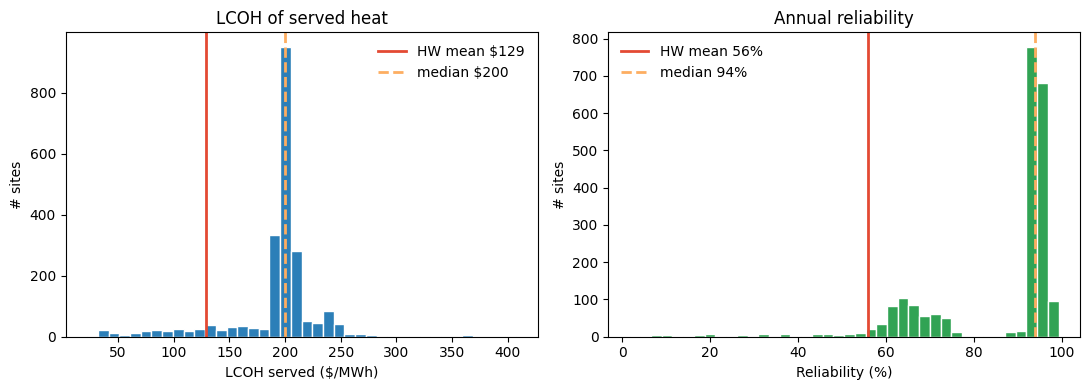

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(ok["LCOH_served_$perMWh"].clip(upper=500), bins=40, color="#2c7fb8", edgecolor="white")
axes[0].axvline(hw(ok["LCOH_served_$perMWh"]), color="#e34a33", lw=2, label=f"HW mean ${hw(ok['LCOH_served_$perMWh']):.0f}")
axes[0].axvline(ok["LCOH_served_$perMWh"].median(), color="#fdae61", lw=2, ls="--", label=f"median ${ok['LCOH_served_$perMWh'].median():.0f}")
axes[0].set_xlabel("LCOH served ($/MWh)"); axes[0].set_ylabel("# sites")
axes[0].set_title("LCOH of served heat"); axes[0].legend(frameon=False)

axes[1].hist(ok["Reliability_%"], bins=40, color="#31a354", edgecolor="white")
axes[1].axvline(hw(ok["Reliability_%"]), color="#e34a33", lw=2, label=f"HW mean {hw(ok['Reliability_%']):.0f}%")
axes[1].axvline(ok["Reliability_%"].median(), color="#fdae61", lw=2, ls="--", label=f"median {ok['Reliability_%'].median():.0f}%")
axes[1].set_xlabel("Reliability (%)"); axes[1].set_ylabel("# sites")
axes[1].set_title("Annual reliability"); axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT / "multiband_lcoh_reliability_hist.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. By subsector

,n_sites,heat_TWh,served_TWh,hw_LCOH,hw_reliability_%,hw_hp_share_%,median_solar_MWdc_per_MWth
subsector,,,,,,,
petrochemical-steam-cracking,36.0,152.26,41.82,59.65,27.47,0.00,2.40
iron-and-steel,112.0,101.35,32.99,77.25,32.55,0.01,10.89
food-beverage-tobacco,868.0,98.37,92.47,201.45,94.00,83.55,3.14
cement,198.0,54.07,32.34,156.81,59.80,0.00,15.27
chemicals,49.0,43.09,30.11,165.41,69.88,40.21,8.66
pulp-and-paper,79.0,18.22,18.01,243.21,98.89,97.05,0.55
textiles-leather-apparel,612.0,17.67,17.04,198.64,96.46,90.00,1.62
glass,148.0,16.26,11.68,202.69,71.86,22.27,14.53
lime,62.0,10.91,6.28,157.54,57.56,0.00,15.44



BY SUBSECTOR (heat-weighted)
  subsector                            n  heat_TWh   served    LCOH   rel%   HP%
  petrochemical-steam-cracking        36     152.3     41.8      60     27     0
  iron-and-steel                     112     101.3     33.0      77     33     0
  food-beverage-tobacco              868      98.4     92.5     201     94    84
  cement                             198      54.1     32.3     157     60     0
  chemicals                           49      43.1     30.1     165     70    40
  pulp-and-paper                      79      18.2     18.0     243     99    97
  textiles-leather-apparel           612      17.7     17.0     199     96    90
  glass                              148      16.3     11.7     203     72    22
  lime                                62      10.9      6.3     158     58     0
  aluminum                            28      10.1      8.8     229     87    75


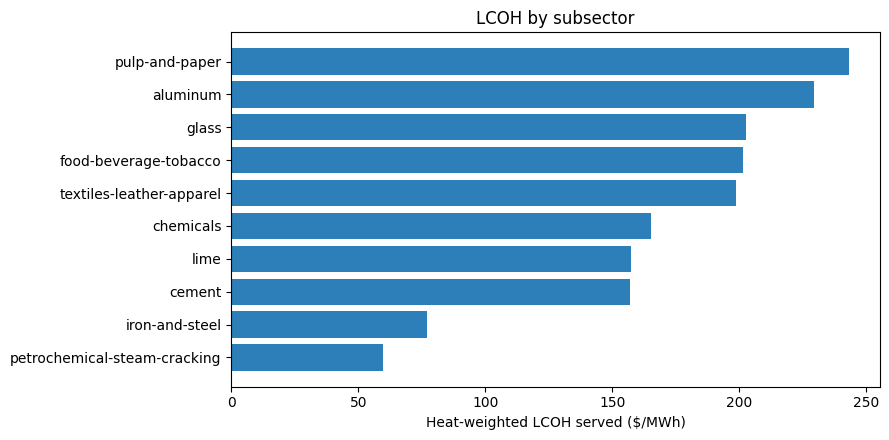

In [4]:
sec = (ok.groupby("subsector")
       .apply(lambda g: pd.Series({
           "n_sites": len(g),
           "heat_TWh": g["replaceable_heat_mwh_th"].sum() / 1e6,
           "served_TWh": g["served_mwh"].sum() / 1e6,
           "hw_LCOH": (g["LCOH_served_$perMWh"] * g["replaceable_heat_mwh_th"]).sum() / g["replaceable_heat_mwh_th"].sum(),
           "hw_reliability_%": (g["Reliability_%"] * g["replaceable_heat_mwh_th"]).sum() / g["replaceable_heat_mwh_th"].sum(),
           "hw_hp_share_%": 100 * (g["hp_load_MW"] * g["replaceable_heat_mwh_th"]).sum() / (g["total_load_MW"] * g["replaceable_heat_mwh_th"]).sum(),
           "median_solar_MWdc_per_MWth": g["solar_per_load_MWdc_per_MWth"].median(),
       }), include_groups=False)
       .sort_values("heat_TWh", ascending=False)
       .round(2))
display(sec)

add("")
add("BY SUBSECTOR (heat-weighted)")
add(f"  {'subsector':<32} {'n':>5} {'heat_TWh':>9} {'served':>8} {'LCOH':>7} {'rel%':>6} {'HP%':>5}")
for s, r in sec.iterrows():
    add(f"  {s:<32} {int(r.n_sites):5d} {r.heat_TWh:9.1f} {r.served_TWh:8.1f} {r.hw_LCOH:7.0f} {r['hw_reliability_%']:6.0f} {r['hw_hp_share_%']:5.0f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
plot = sec.sort_values("hw_LCOH")
ax.barh(plot.index, plot["hw_LCOH"], color="#2c7fb8")
ax.set_xlabel("Heat-weighted LCOH served ($/MWh)")
ax.set_title("LCOH by subsector")
fig.tight_layout()
fig.savefig(OUT / "multiband_lcoh_by_subsector.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. By country (top heat)

,n_sites,heat_TWh,served_TWh,hw_LCOH,hw_reliability_%
iso3_country,,,,,
DEU,201.0,119.72,55.23,116.35,46.13
FRA,272.0,56.18,35.15,131.46,62.57
NLD,97.0,47.84,16.02,82.31,33.49
ITA,339.0,47.72,33.15,139.08,69.46
ESP,188.0,39.97,27.03,122.95,67.62
GBR,290.0,32.85,18.90,153.60,57.52
POL,179.0,30.69,20.66,172.93,67.32
BEL,66.0,30.41,12.57,105.05,41.34
SWE,27.0,15.10,7.00,128.87,46.38



BY COUNTRY — top 15 by replaceable heat
  iso        n  heat_TWh   served    LCOH   rel%
  DEU      201     119.7     55.2     116     46
  FRA      272      56.2     35.1     131     63
  NLD       97      47.8     16.0      82     33
  ITA      339      47.7     33.1     139     69
  ESP      188      40.0     27.0     123     68
  GBR      290      32.9     18.9     154     58
  POL      179      30.7     20.7     173     67
  BEL       66      30.4     12.6     105     41
  SWE       27      15.1      7.0     129     46
  AUT       33      14.7      6.7     105     46
  CZE       45      11.7      7.4     154     63
  ROU       54      10.8      7.4     154     68
  PRT      158      10.0      7.2     127     72
  FIN       29       8.8      4.3     143     49
  HUN       16       8.5      5.8     137     68


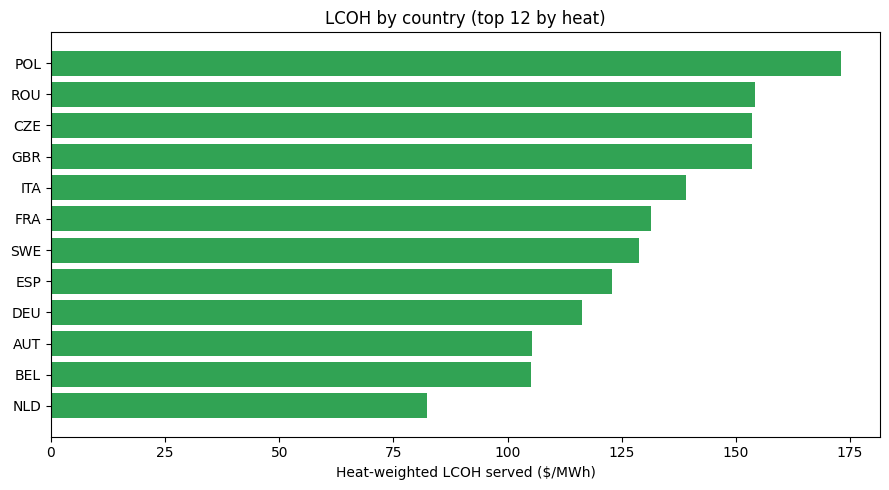

In [5]:
cty = (ok.groupby("iso3_country")
       .apply(lambda g: pd.Series({
           "n_sites": len(g),
           "heat_TWh": g["replaceable_heat_mwh_th"].sum() / 1e6,
           "served_TWh": g["served_mwh"].sum() / 1e6,
           "hw_LCOH": (g["LCOH_served_$perMWh"] * g["replaceable_heat_mwh_th"]).sum() / g["replaceable_heat_mwh_th"].sum(),
           "hw_reliability_%": (g["Reliability_%"] * g["replaceable_heat_mwh_th"]).sum() / g["replaceable_heat_mwh_th"].sum(),
       }), include_groups=False)
       .sort_values("heat_TWh", ascending=False)
       .round(2))
display(cty.head(15))

add("")
add("BY COUNTRY — top 15 by replaceable heat")
add(f"  {'iso':<6} {'n':>5} {'heat_TWh':>9} {'served':>8} {'LCOH':>7} {'rel%':>6}")
for s, r in cty.head(15).iterrows():
    add(f"  {s:<6} {int(r.n_sites):5d} {r.heat_TWh:9.1f} {r.served_TWh:8.1f} {r.hw_LCOH:7.0f} {r['hw_reliability_%']:6.0f}")

fig, ax = plt.subplots(figsize=(9, 5))
plot = cty.head(12).sort_values("hw_LCOH")
ax.barh(plot.index, plot["hw_LCOH"], color="#31a354")
ax.set_xlabel("Heat-weighted LCOH served ($/MWh)")
ax.set_title("LCOH by country (top 12 by heat)")
fig.tight_layout()
fig.savefig(OUT / "multiband_lcoh_by_country.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Reliability vs cost and solar intensity

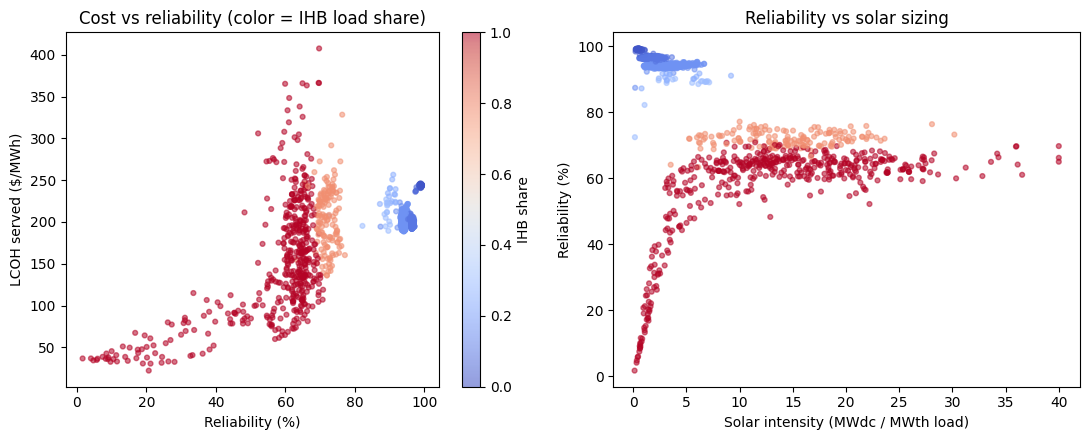

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sc = axes[0].scatter(ok["Reliability_%"], ok["LCOH_served_$perMWh"].clip(upper=600),
                     c=ok["ihb_share"], cmap="coolwarm", s=12, alpha=0.55, vmin=0, vmax=1)
axes[0].set_xlabel("Reliability (%)"); axes[0].set_ylabel("LCOH served ($/MWh)")
axes[0].set_title("Cost vs reliability (color = IHB load share)")
plt.colorbar(sc, ax=axes[0], label="IHB share")

axes[1].scatter(ok["solar_per_load_MWdc_per_MWth"].clip(upper=40),
                ok["Reliability_%"], c=ok["ihb_share"], cmap="coolwarm",
                s=12, alpha=0.55, vmin=0, vmax=1)
axes[1].set_xlabel("Solar intensity (MWdc / MWth load)")
axes[1].set_ylabel("Reliability (%)")
axes[1].set_title("Reliability vs solar sizing")
fig.tight_layout()
fig.savefig(OUT / "multiband_reliability_cost_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Write text summary

In [7]:
add("")
add("NOTES")
add("  LCOH_served = annualized system cost / served heat (excludes VoLL on unserved).")
add("  Reliability < 100% usually means land-capped solar cannot cover full load year-round.")
add("  High-temp (IHB) sites need more solar per MWth than HP-dominated sites (COP 1 vs 1.8–2.7).")
add("")
add("Files:")
add(f"  results CSV:  outputs/multiband_hp_ihb_by_facility.csv")
add(f"  run log:      outputs/multiband_run_log.txt")
add(f"  figures:      outputs/analysis/multiband_*.png")
add("=" * 72)

summary_path = OUT / "multiband_optimization_summary.txt"
summary_path.write_text("\n".join(lines) + "\n")
print(f"\nWrote {summary_path}")


NOTES
  LCOH_served = annualized system cost / served heat (excludes VoLL on unserved).
  Reliability < 100% usually means land-capped solar cannot cover full load year-round.
  High-temp (IHB) sites need more solar per MWth than HP-dominated sites (COP 1 vs 1.8–2.7).

Files:
  results CSV:  outputs/multiband_hp_ihb_by_facility.csv
  run log:      outputs/multiband_run_log.txt
  figures:      outputs/analysis/multiband_*.png

Wrote /Users/annayuen/Desktop/IECC/industrial_decarb/facility_IHB_potential/outputs/analysis/multiband_optimization_summary.txt
